In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
import sys
sys.path.append("../src")
from utils import set_theme_and_plot_params
import catppuccin
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import seasonal_decompose

FE_DF_PATH = Path("../data/processed/feature_engineered_df.parquet")
fe_df = pd.read_parquet(FE_DF_PATH)

In [84]:
# look at the feature engineered dataframe
fe_df.head()

,Store,DayOfWeek,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,...,Month,Day,WeekOfYear,Quarter,IsWeekend,Season,CompetitionExists,WasPromo2Active,CompetitionAgeMonths,Sales
0,1,5,555,1,1,0,1,c,a,1270,...,7,31,31,3,0,Summer,1,0,82,5263
1,2,5,625,1,1,0,1,a,a,570,...,7,31,31,3,0,Summer,1,1,92,6064
2,3,5,821,1,1,0,1,a,a,14130,...,7,31,31,3,0,Summer,1,1,103,8314
3,4,5,1498,1,1,0,1,c,c,620,...,7,31,31,3,0,Summer,1,0,70,13995
4,5,5,559,1,1,0,1,a,a,29910,...,7,31,31,3,0,Summer,1,0,3,4822


In [85]:
# info
fe_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 27 columns):
 #   Column                     Non-Null Count    Dtype   
---  ------                     --------------    -----   
 0   Store                      1017209 non-null  int16   
 1   DayOfWeek                  1017209 non-null  int8    
 2   Customers                  1017209 non-null  int16   
 3   Open                       1017209 non-null  int8    
 4   Promo                      1017209 non-null  int8    
 5   StateHoliday               1017209 non-null  category
 6   SchoolHoliday              1017209 non-null  int8    
 7   StoreType                  1017209 non-null  category
 8   Assortment                 1017209 non-null  category
 9   CompetitionDistance        1017209 non-null  int32   
 10  CompetitionOpenSinceMonth  1017209 non-null  int16   
 11  CompetitionOpenSinceYear   1017209 non-null  int16   
 12  Promo2                     1017209 non-null  int64   
 13  Promo2Si

In [86]:
# shape
fe_df.shape

(1017209, 27)

In [87]:
# check NaN values
fe_df.isna().sum()

Store                        0
DayOfWeek                    0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Year                         0
Month                        0
Day                          0
WeekOfYear                   0
Quarter                      0
IsWeekend                    0
Season                       0
CompetitionExists            0
WasPromo2Active              0
CompetitionAgeMonths         0
Sales                        0
dtype: int64

# Exploratory Data Analysis

In [88]:
# set theme and plot params
set_theme_and_plot_params()

### Target Analysis

In [89]:
# basic statistics
fe_df.Sales.describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

Is Sales skewed? Are there extreme values?

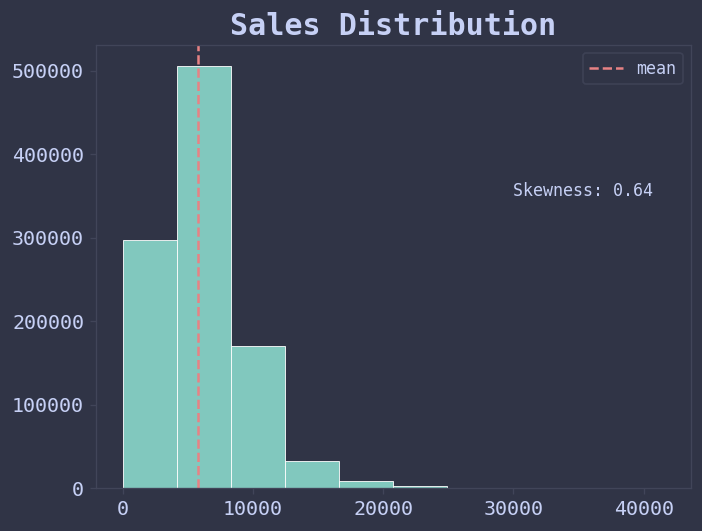

In [ ]:
sales_stats = fe_df.Sales.agg(["mean", "skew"]).round(2)

plt.hist(fe_df.Sales, edgecolor="white", linewidth=0.5, color=catppuccin.PALETTE.frappe.colors.teal.hex)
plt.text(30_000, 350_000, s=f"Skewness: {sales_stats.iloc[1]}")
plt.axvline(sales_stats.iloc[0], color=catppuccin.PALETTE.frappe.colors.red.hex, linestyle="--", label="mean")
plt.title("Sales Distribution")
plt.legend()
plt.show()

### Numerical Feature Analysis

How is Customers feature distributed? Are there outliers?

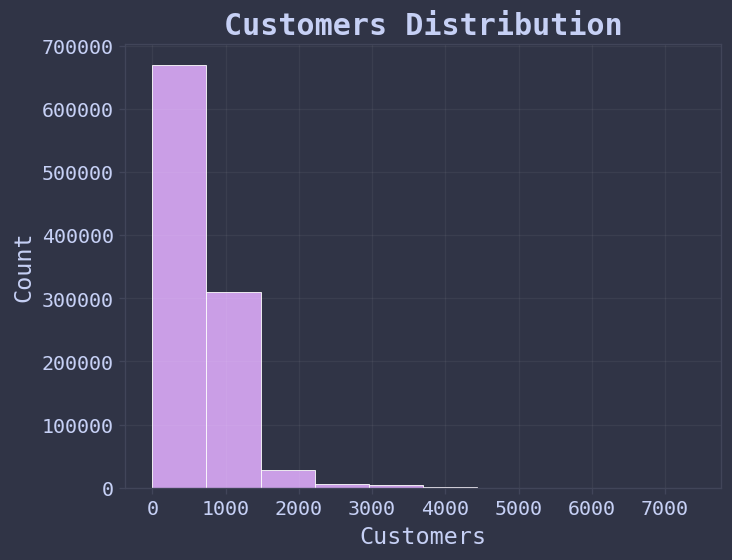

In [91]:
plt.hist(fe_df.Customers, edgecolor="white", linewidth=0.5, color=catppuccin.PALETTE.frappe.colors.mauve.hex)
plt.title("Customers Distribution")
plt.xlabel("Customers")
plt.ylabel("Count")
plt.grid(alpha=0.05, color="white")
plt.show()

Are there many outliers?

In [92]:
customers_z_scores = stats.zscore(fe_df.Customers)
outliers = (abs(customers_z_scores > 3)).sum()
print(f"Sales Outliers Count: {outliers}")

Sales Outliers Count: 14148


Do many stores engage in continuous promotions?

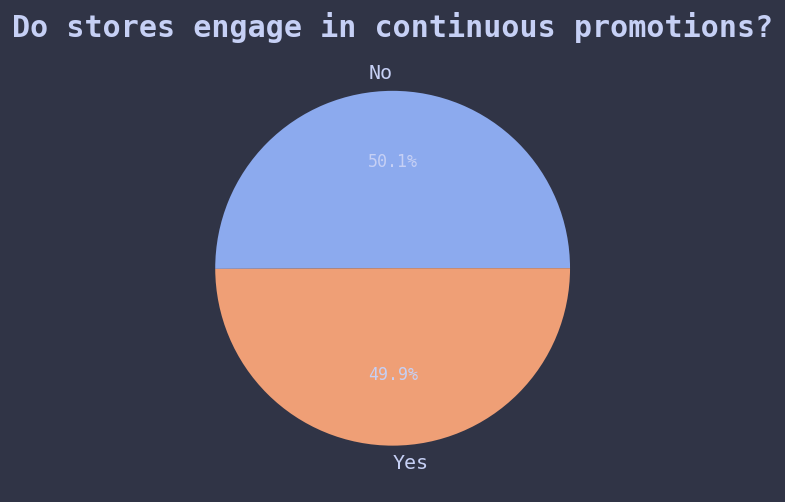

In [93]:
continuous_prom_store_perc_counts = fe_df.Promo2.value_counts()

plt.pie(continuous_prom_store_perc_counts.values, autopct="%1.1f%%", labels=["No", "Yes"])
plt.title("Do stores engage in continuous promotions?")
plt.show()

Is the competition closer to stores that don't make a continuous promotion?

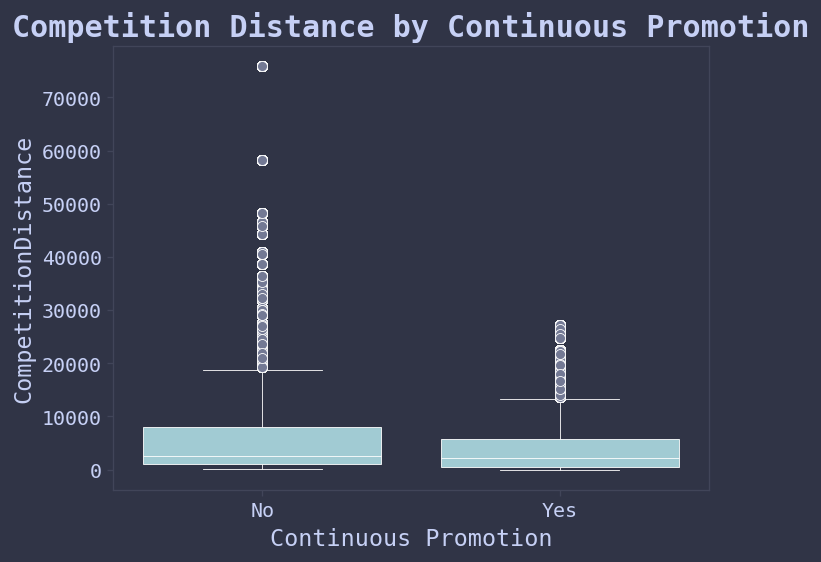

In [ ]:
sns.boxplot(data=fe_df, x="Promo2", y="CompetitionDistance", color=catppuccin.PALETTE.frappe.colors.sky.hex, linecolor="white", linewidth=0.5,
            flierprops={"markeredgewidth": 0.5})
plt.xlabel("Continuous Promotion")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.title("Competition Distance by Continuous Promotion")
plt.show()

If there is competition nearby, are customer counts lower?

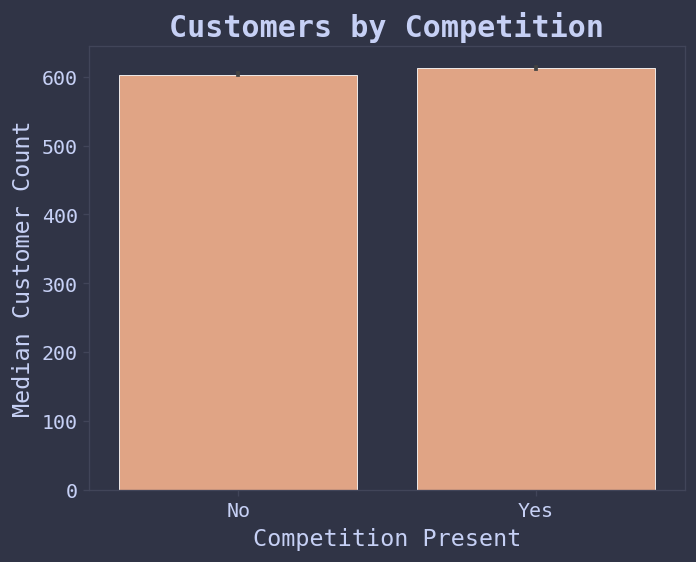

In [95]:
sns.barplot(data=fe_df, x="CompetitionExists", y="Customers", estimator="median", color=catppuccin.PALETTE.frappe.colors.peach.hex, 
            linewidth=0.5, edgecolor="white")
plt.xlabel("Competition Present")
plt.ylabel("Median Customer Count")
plt.xticks([0, 1], ["No", "Yes"])
plt.title("Customers by Competition")
plt.show()

### Categorical Feature Analysis

Are customer counts higher in some seasons, on average?

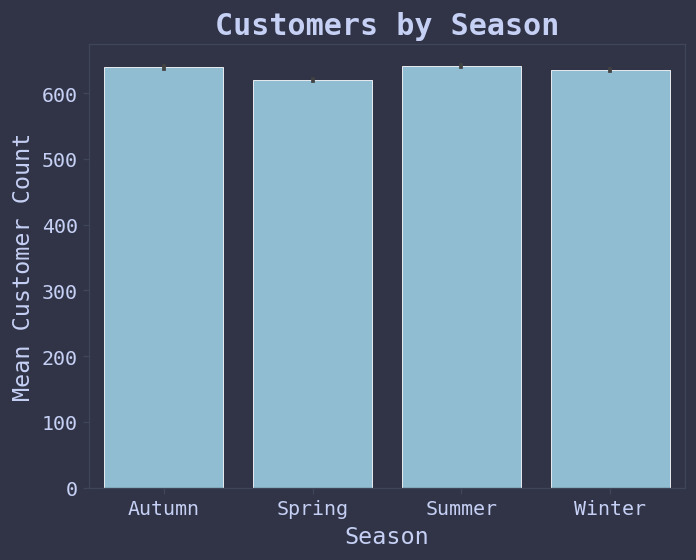

In [ ]:
sns.barplot(data=fe_df, x="Season", y="Customers", edgecolor="white", linewidth=0.5, color=catppuccin.PALETTE.frappe.colors.sapphire.hex)
plt.title("Customers by Season")
plt.ylabel("Mean Customer Count")
plt.show()

Do higher-assortment stores have more customers?

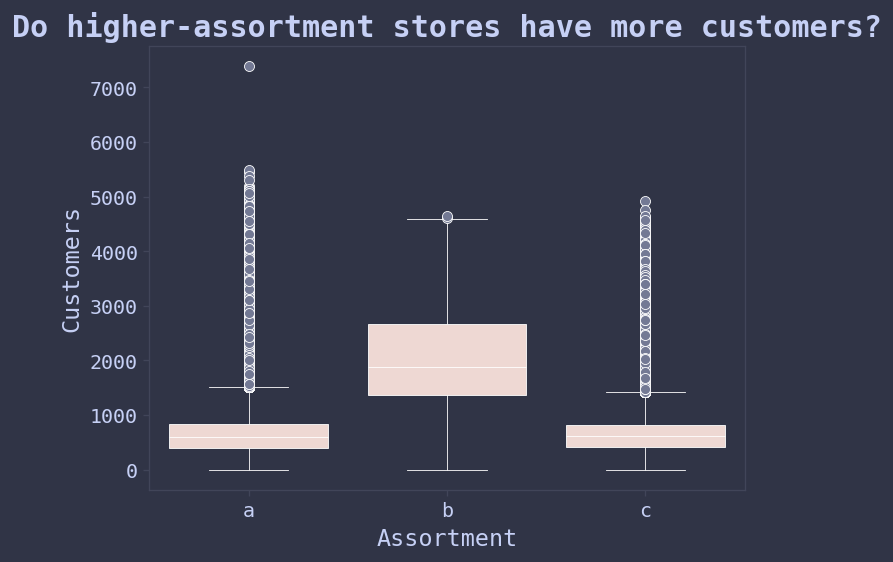

In [97]:
sns.boxplot(data=fe_df, x="Assortment", y="Customers", color=catppuccin.PALETTE.frappe.colors.rosewater.hex, linewidth=0.5, linecolor="white",
            flierprops={"markeredgewidth": 0.5})
plt.title("Do higher-assortment stores have more customers?")
plt.show()

Have some store types had lower competition?

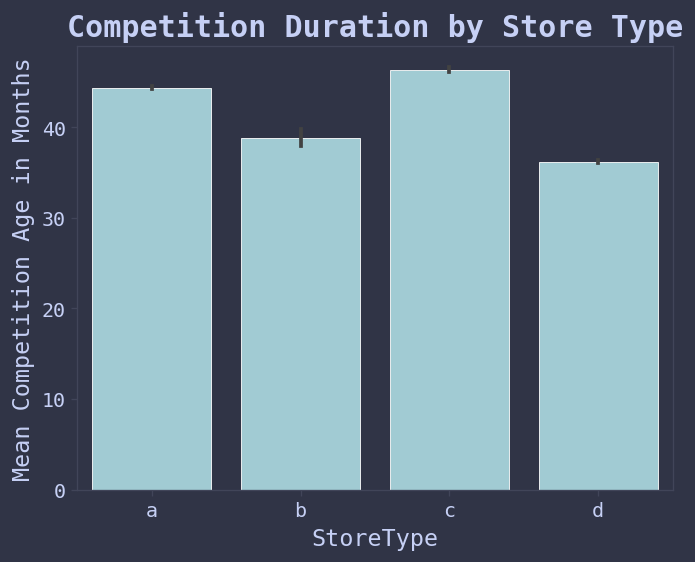

In [ ]:
sns.barplot(data=fe_df, x="StoreType", y="CompetitionAgeMonths", edgecolor="white", linewidth=0.5, color=catppuccin.PALETTE.frappe.colors.sky.hex)
plt.title("Competition Duration by Store Type")
plt.ylabel("Mean Competition Age in Months")
plt.show()

### Feature vs Target Analysis

Do higher-assortment stores have more sales?

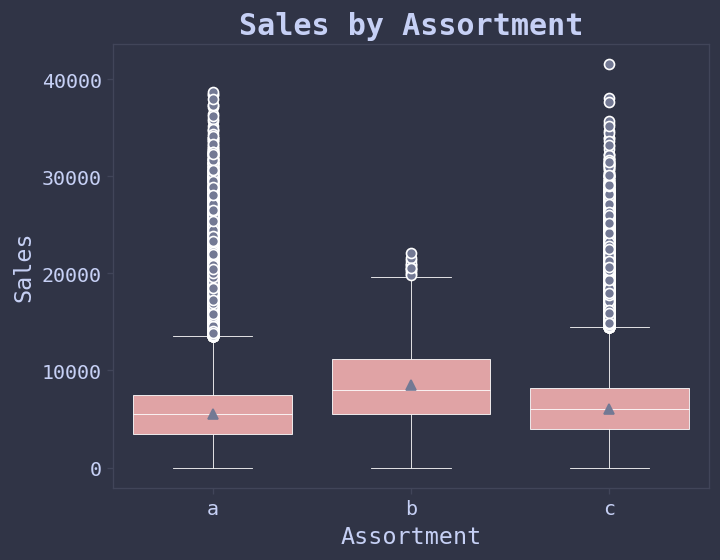

In [ ]:
sns.boxplot(data=fe_df, x="Assortment", y="Sales", showmeans=True, linecolor="white", color=catppuccin.PALETTE.frappe.colors.maroon.hex,
            linewidth=0.5, flierprops={"markeredgecolor": "white"})
plt.title("Sales by Assortment")
plt.show()

Do some months have higher median sales? Does being on a countinuous promotion influence sales?

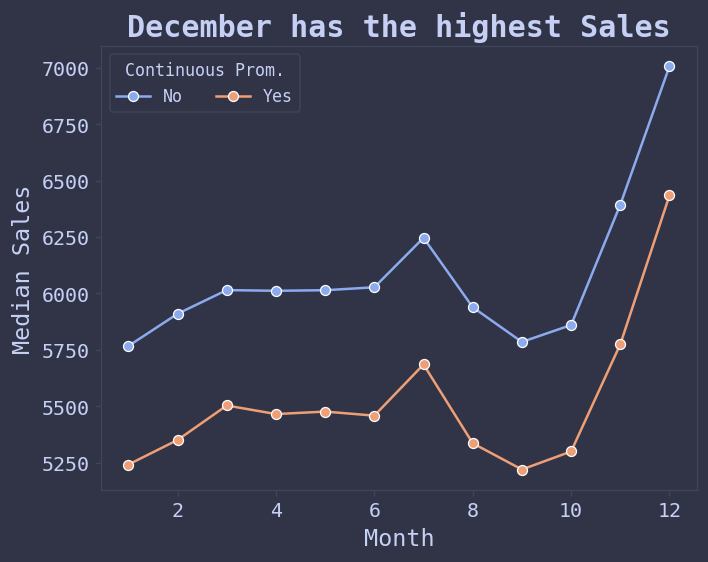

In [ ]:
sns.lineplot(data=fe_df, x="Month", y="Sales", estimator="median", hue="Promo2", style="Promo2", markers=["o", "o"], dashes=False, 
             errorbar=None)
plt.ylabel("Median Sales")
plt.title("December has the highest Sales")
plt.legend(title="Continuous Prom.", labels=["No", "Yes"], ncols=2)
plt.show()

### Correlation Analysis

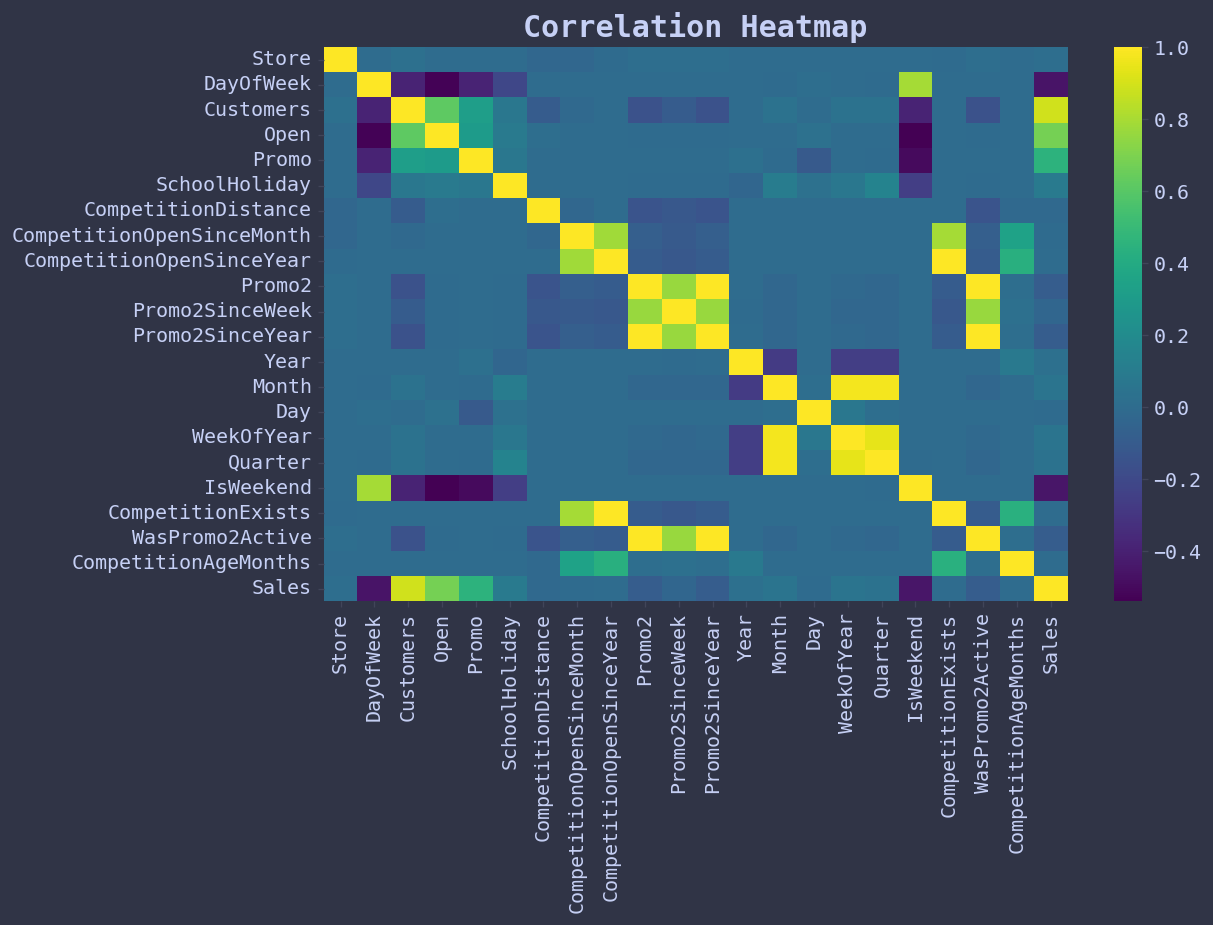

In [101]:
corrs = fe_df.corr(numeric_only=True).round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(corrs, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

Which are the most correlated with sales?

In [102]:
fe_df.corr(numeric_only=True)["Sales"].sort_values(ascending=False).round(2)

Sales                        1.00
Customers                    0.89
Open                         0.68
Promo                        0.45
SchoolHoliday                0.09
WeekOfYear                   0.05
Month                        0.05
Quarter                      0.04
Year                         0.02
Store                        0.01
CompetitionOpenSinceYear     0.00
CompetitionExists            0.00
CompetitionAgeMonths        -0.00
Day                         -0.01
CompetitionOpenSinceMonth   -0.01
CompetitionDistance         -0.02
Promo2SinceWeek             -0.04
WasPromo2Active             -0.09
Promo2                      -0.09
Promo2SinceYear             -0.09
IsWeekend                   -0.45
DayOfWeek                   -0.46
Name: Sales, dtype: float64

### Advanced Statistics

Is there a significant difference in sales during promotions?

In [103]:
# Mann-Whitney U test
promo = fe_df.loc[fe_df.Promo == 1, "Sales"]
no_promo = fe_df.loc[fe_df.Promo == 0, "Sales"]
mann_whitney_stat, mann_whitney_stat_p_value = stats.mannwhitneyu(promo, no_promo)

print(f"u-stat: {mann_whitney_stat} | p-value: {mann_whitney_stat_p_value}")

u-stat: 192934752560.5 | p-value: 0.0


Do school holidays affect sales?

In [104]:
school_hol_sales = fe_df.loc[fe_df.SchoolHoliday == 1, "Sales"]
no_school_hol_sales = fe_df.loc[fe_df.SchoolHoliday == 0, "Sales"]
school_hol_m_w_stat, school_hol_m_w_p_value = stats.mannwhitneyu(school_hol_sales, no_school_hol_sales)

print(f"u-stat: {school_hol_m_w_stat} | p-value: {school_hol_m_w_p_value}")

u-stat: 85430006428.0 | p-value: 0.0


Is the average store sales significantly different across store type?

In [105]:
f_stat, p_value = stats.f_oneway(
    fe_df[fe_df.StoreType == "a"]["Sales"],
    fe_df[fe_df.StoreType == "b"]["Sales"],
    fe_df[fe_df.StoreType == "c"]["Sales"],
    fe_df[fe_df.StoreType == "d"]["Sales"],
)

print(f"f-stat: {round(f_stat, 2)} | p-value: {round(p_value, 2)}")

f-stat: 6817.19 | p-value: 0.0


Which types are significantly different?

In [106]:
tukey_hsd = pairwise_tukeyhsd(endog=fe_df.Sales, groups=fe_df.StoreType, alpha=0.05)

tukey_hsd_table = pd.DataFrame(data=tukey_hsd._results_table.data[1:], columns=tukey_hsd._results_table.data[0])
tukey_hsd_table

,group1,group2,meandiff,p-adj,lower,upper,reject
0,a,b,4320.6576,0.000,4241.7165,4399.5987,True
1,a,c,-14.5505,0.586,-44.1246,15.0237,False
2,a,d,-96.3605,0.000,-118.2763,-74.4446,True
3,b,c,-4335.2081,0.000,-4417.4191,-4252.9971,True
4,b,d,-4417.0181,0.000,-4496.7948,-4337.2414,True
5,c,d,-81.8100,0.000,-113.5472,-50.0728,True


Which variables are highly correlated?

In [107]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# keep only non-redundant features
num_features = ["Store", "Customers", "Open", "Promo", 
                "SchoolHoliday", "CompetitionDistance", "CompetitionAgeMonths", 
                "WasPromo2Active", "Year", "Month", "DayOfWeek"]

X = fe_df[num_features].astype("float64")
vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# look at the result
vif.sort_values("VIF", ascending=False)

,Feature,VIF
8,Year,30.887661
2,Open,11.531507
10,DayOfWeek,7.882289
1,Customers,5.109715
9,Month,4.146685
0,Store,4.015814
7,WasPromo2Active,2.138159
3,Promo,1.991535
5,CompetitionDistance,1.570564
6,CompetitionAgeMonths,1.414653


Time Series Analysis

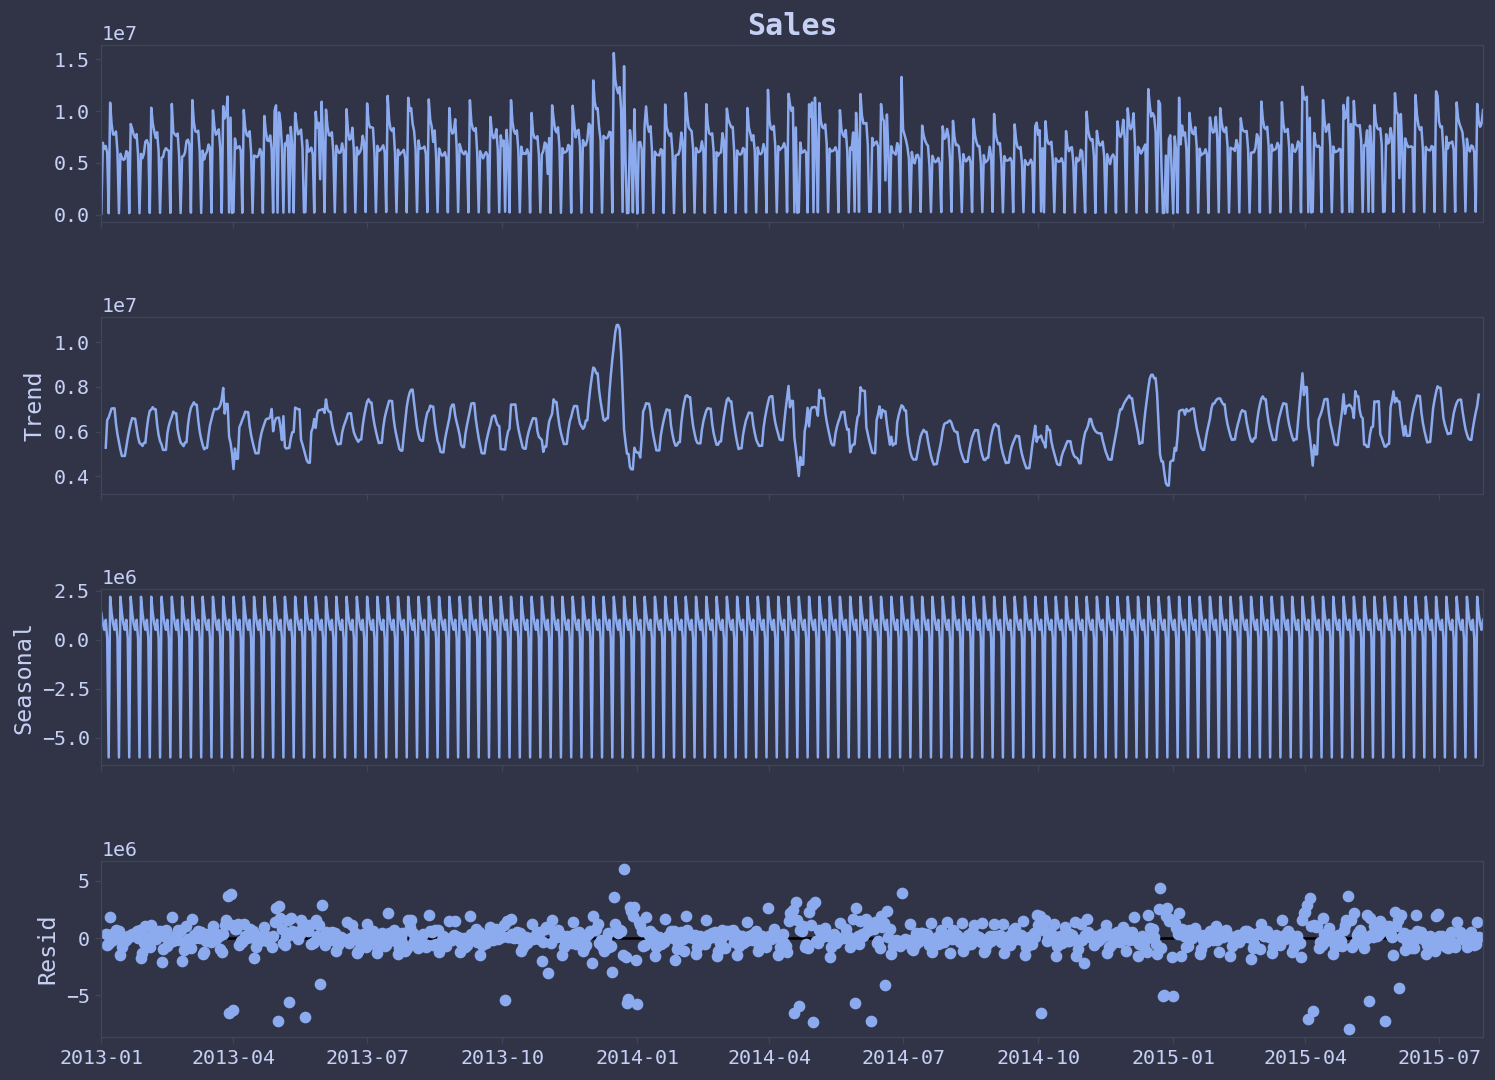

In [ ]:
time_series_df = fe_df[["Year", "Month", "Day", "Sales"]]
time_series_df["Date"] = pd.to_datetime(fe_df[["Year", "Month", "Day"]])

# aggregate sales by date
daily_sales = time_series_df.groupby("Date")["Sales"].sum().sort_index()

# decompose the series
decomposition = seasonal_decompose(daily_sales, model="additive", period=7)

# plot
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

# Exploratory Data Analysis Conclusions

1.	Target Analysis: sales aren’t normally distributed and are right-skewed (skewness of 0.64), suggesting that there are a few stores that record large sales values.
2.	Numerical Feature Analysis:
-	Customers feature isn’t normally distributed and 14148 values are outliers, having a z-score above 3.
-	Roughly half of stores engage in a continuous promotion, according to the data.
-	Whether or not a store is engaged in a continuous promotion doesn’t suggest lower competition nearby. The competition distance distribution is roughly the same, though there are a few outliers regarding stores that don’t engage in such a promotion. In the last case, some competitors are very far away, reaching even more than 40km.
-	If a store has competition nearby, median customer counts aren’t meaningfully different, according to the data. 
3.	Categorical Feature Analysis:
-	Average customers per season are highest during summer, followed by autumn, winter and spring.
-	Stores with extra assortment have more customers than in the other two categories (basic and extended). Nonetheless, basic-assortment-type and extended-assortment-type stores have many outliers, some of which go beyond the upper bound of extra-assortment-type stores.
-	c-type stores have had more competition (measured in months), on average, reaching ≈46.4 months, followed by a-type stores (≈44.4), b-type stores (≈38.8) and d-type stores (≈36.2).
4.	Feature vs. Target Analysis:
-	Stores with extra assortment have more sales than in the other two categories (basic and extended). As with customers, the other two categories exhibit many outliers, suggesting that some stores generate significantly higher sales.
-	Whether or not a store is on a continuous promotion cycle, December is the highest grossing month, according to the data, generating significantly more sales than in other months.
5.	Correlation Analysis:
-	Features most correlated with the target are Customers (0.89), Open (0.68) and Promo (0.45).
6.	Advanced Statistics:
-	Since Sales doesn’t follow a normal distribution I used Mann-Whitney U Test to compare sales across two categories. The high u-stat and <0.05 p-value for both suggest that sales are significantly different across groups, whether or not a store is on promotion or there is school holiday. 
-	ANOVA analysis also identified statistical difference in sales between store types. Nonetheless, Tukey HSD identified not all groups are significantly different. For instance, a-type and c-type stores aren’t, with the latter having 14.6k average sales lower than the other.
-	Variance Inflation Factor (VIF): it was performed to assess multicollinearity among some numerical features. After ensuring numerical stability and removing redundant variables, results showed high VIF values for Year (30.8) and Open (11.5). The high VIF for Open suggests strong linear dependence with other predictors (such as Customers), which is expected because customer traffic is only observed when stores are open.
-	Time Series Analysis: 
1.	Observed: the raw sales series exhibits a pronounced weekly cycle with recurring sharp declines, corresponding to days when many stores are closed. Several unusually large spikes are also visible, suggesting the influence of promotions or holiday shopping periods.
2.	Trend: the overall trend is fairly stable but without a clear long-term upward or downward direction. This suggests that sales are driven more by recurring seasonal effects and special events than by a steady long-term growth trend.
3.	Seasonal: the seasonal component reveals a highly regular weekly pattern. Sales consistently fall on one day each week, reflecting widespread Sunday store closures, while weekdays exhibit positive seasonal effects. 
4.	Residuals: after removing trend and seasonal effects, the remaining residuals contain several large deviations, suggesting that promotions, holidays and other exceptional events explain additional variability in sales.